# How many attention heads does a task need? Built by hand

This notebook rebuilds the whole project from scratch, in small steps you can do yourself.
Every section has the same five parts:

1. **Idea**: what we are doing, in plain words.
2. **By hand**: the same thing on numbers small enough for pen and paper.
3. **Your turn**: step-by-step instructions to write the code yourself. Try it in a new cell
   before reading the solution.
4. **Solution and check**: short code, and a check that it matches the by-hand numbers.
5. **Real result**: what the full experiments (hundreds of saved runs) found.

Everything here runs on a CPU in about two minutes. Only numpy, PyTorch and matplotlib are
needed for sections 1 to 8; the real-result cells read the saved runs in `results/`.

| section | what you build |
|---|---|
| 1 | the task: a memory, a query, and four answers |
| 2 | one attention head |
| 3 | why the task needs exactly $R$ heads (one head, one equation) |
| 4 | a layer of many heads, trained from scratch |
| 4b | the real model in the repo, every line explained |
| 5 | the supply valve on each head |
| 6 | the collateral value: what nobody else can cover |
| 6b | everything as matrices, by hand: every shape and every number |
| 6c | where the valve and the collateral value live in the real code |
| 6d | the whole task in L-shapes, spreadsheet style |
| 7 | the collateral rule, running during training |
| 8 | what the full experiments found |
| 9 | backup heads when heads can fail |
| 10 | a second circuit: two-layer induction |
| 11 | what holds and what does not |

In [1]:
import glob, pickle, sys                           # files, saved results, import paths
from math import comb                              # binomial coefficients (section 9)
import numpy as np                                 # plain arrays and least squares
import torch                                       # tensors, automatic gradients, training
import torch.nn.functional as F                    # softmax, one-hot, loss functions
import matplotlib.pyplot as plt                    # plots

RED, GREY = "#b2182b", "#888888"                   # colours used in the plots
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})              # plot style
torch.set_num_threads(4)                           # use 4 CPU cores
sys.path.insert(0, "../src")                       # so we can import the repo's own code later
print("ready")

ready


## 1. The task

**Idea.** A memory has $N$ slots. Slot $j$ holds a random vector $c_j$ (its *content*). A
query arrives holding a position $p$. The model must return the contents found $\delta_1,
\dots, \delta_R$ slots ahead of $p$, wrapping around like a clock:

$$\text{answer} = (c_{p+\delta_1},\ \dots,\ c_{p+\delta_R}), \qquad \text{positions taken mod } N.$$

**By hand.** $N = 8$ slots, $R = 2$ offsets $\delta = (1, 5)$, query $p = 6$:
$(6 + 1) \bmod 8 = 7$ and $(6 + 5) \bmod 8 = 3$. The answer is $(c_7, c_3)$.

**Your turn.** Write `make_batch(B)` that returns `query, memory, answer`:
1. Draw `B` positions `p` uniformly from `0..N-1`.
2. Draw contents `content` of shape `(B, N, m)` from a standard normal.
3. The query is the one-hot vector of `p`: shape `(B, N)`.
4. The memory row for slot `j` is `[one-hot of j, content of j]`: shape `(B, N, N + m)`.
5. The answer stacks `content[(p + delta_r) mod N]` for each offset: shape `(B, R * m)`.

In [2]:
N, R, m = 8, 2, 4                                   # N slots, R offsets (= heads needed), m numbers per item
OFFSETS = [1 + r * N // R for r in range(R)]          # the offsets, evenly spread: (1, 5)


def make_batch(B, gen=None):                         # B = how many examples to make
    p = torch.randint(0, N, (B,), generator=gen)     # each query's position, 0..N-1
    content = torch.randn(B, N, m, generator=gen)    # the random item stored in every slot
    query = F.one_hot(p, N).float()                  # the query is the one-hot code of p: (B, N)
    memory = torch.cat([torch.eye(N).expand(B, N, N), content], 2)  # slot j = [one-hot j, item j]: (B, N, N+m)
    idx = (p[:, None] + torch.tensor(OFFSETS)[None]) % N            # which slots to fetch: p + offset, wrapped
    answer = torch.gather(content, 1, idx[..., None].expand(B, R, m)).reshape(B, R * m)  # those items, stacked
    return query, memory, answer, p, content         # p and content are returned only for checking


q, mem, ans, p, content = make_batch(1, torch.Generator().manual_seed(0))  # one example, fixed seed
p0 = int(p[0])                                       # its query position
print("offsets", OFFSETS, "  query position p =", p0)
for r, d in enumerate(OFFSETS):                      # for each offset ...
    slot = (p0 + d) % N                              # ... the slot it points to
    print(f"  ({p0} + {d}) mod {N} = {slot}:  answer block {r} equals content of slot {slot}:",
          torch.equal(ans[0, r * m:(r + 1) * m], content[0, slot]))  # check the answer holds that item

offsets [1, 5]   query position p = 4
  (4 + 1) mod 8 = 5:  answer block 0 equals content of slot 5: True
  (4 + 5) mod 8 = 1:  answer block 1 equals content of slot 1: True


## 2. One attention head

**Idea.** A head turns the query into a *query vector* $q$, each memory slot into a *key*
$k_j$ and a *value* $v_j$. It scores each slot by $q \cdot k_j$, turns the scores into
weights that are positive and sum to one (the softmax), and returns the weighted average of
the values:

$$a_j = \frac{e^{q\cdot k_j}}{\sum_i e^{q \cdot k_i}}, \qquad \text{output} = \sum_j a_j\, v_j .$$

**By hand.** Three slots with scores $(2, 0, 0)$: $e^2 = 7.389$, $e^0 = 1$, so the weights are
$7.389/9.389 = 0.787$ and $1/9.389 = 0.107$ twice. With values $(10, 20, 30)$ the output is
$0.787 \cdot 10 + 0.107 \cdot 20 + 0.107 \cdot 30 = 7.87 + 2.13 + 3.20 = 13.2$: mostly slot 1,
a little of the others. (Keep three decimals: rounding the weights to 0.79 and 0.11 first
gives 13.4, which is wrong.)

**Your turn.** Write `attend(scores, values)`: softmax the scores, then return the weighted sum.
Check it gives 13.2 on the example above.

In [3]:
def attend(scores, values):
    w = torch.softmax(torch.as_tensor(scores, dtype=torch.float), -1)   # scores -> weights that sum to 1
    return w, w @ torch.as_tensor(values, dtype=torch.float)            # weighted average of the values


w, out = attend([2.0, 0.0, 0.0], [10.0, 20.0, 30.0])  # the by-hand example
print("weights", w.numpy().round(3), "  output", round(float(out), 1))
assert abs(float(out) - 13.2) < 0.05                  # must match the hand calculation

weights [0.787 0.107 0.107]   output 13.2


The key fact for everything that follows: **a head returns one weighted average**. If it
splits its attention between two slots it returns a *blend* of their contents, never the two
contents separately.

## 3. One head, one equation: why the task needs exactly $R$ heads

**Idea.** The answer contains $R$ unknown vectors. Each head hands back one blend of them,
which is one equation. To solve for $R$ unknowns you need $R$ *different* equations, so at
least $R$ heads.

**By hand.** Two unknowns $x, y$. One equation, $x + y = 10$: cannot be solved. Add
$x - y = 2$: $x = 6, y = 4$. Add instead $2x + 2y = 20$: still stuck, because it is the first
equation again. The number of different equations is the **rank**.

If each missing equation leaves one of the $R$ unknowns unknown, the best possible error is

$$\text{loss}(k) = \Big(1 - \frac{k}{R}\Big) \times \text{loss of a model that learned nothing.}$$

At $R = 4$: one head leaves $3/4$, two heads $2/4$, three $1/4$, four heads 0.

**Your turn.** Check the formula numerically, without training anything:
1. Draw $R = 4$ unknown vectors per example (many examples), unit variance.
2. Make $k$ random blends: `U = A @ C` with a random `k x 4` matrix `A`.
3. Fit the best linear guess of `C` from `U` with least squares, and measure the error.
4. Compare with $1 - k/4$. Then make one blend a copy of another and see the error.

In [4]:
rng = np.random.default_rng(0)                     # random numbers, fixed seed
Rn, n = 4, 20000                                   # 4 unknowns per example, 20000 examples
C = rng.normal(size=(n, Rn))                       # the unknowns (one number each), unit variance


def best_error(A):                                 # A: one row per head = that head's mixing recipe
    U = C @ A.T                                    # what the heads hand back: one blend per head
    W = np.linalg.lstsq(U, C, rcond=None)[0]       # best linear guess of the unknowns from the blends
    return np.mean((C - U @ W) ** 2)               # how wrong that best guess still is


print("blends  error   predicted 1 - k/4")
for k in range(1, 5):                              # 1, 2, 3, 4 heads (random recipes)
    print(f"{k:>6}  {best_error(rng.normal(size=(k, Rn))):.3f}   {1 - k / Rn:.3f}")
A = rng.normal(size=(3, Rn))                       # 3 different recipes
A_copy = np.vstack([A, A[0]])                      # add a 4th that repeats the 1st (a copied head)
print(f"4 blends with one copy: {best_error(A_copy):.3f}  (same as 3 blends: {1 - 3 / Rn:.3f})")

blends  error   predicted 1 - k/4
     1  0.749   0.750
     2  0.498   0.500
     3  0.249   0.250
     4  0.000   0.000
4 blends with one copy: 0.252  (same as 3 blends: 0.250)


In [5]:
E1 = pickle.load(open("../results/proposal/equations.pkl", "rb"))   # saved by experiments/equations_test.py
print("REAL RESULT: a trained 4-head model, heads removed or copied, read-out re-fitted")
print(f"{'heads used':<22}{'different':>10}{'loss':>8}{'predicted':>11}")
for row in E1["rows"]:                             # one line per combination of heads
    print(f"{row['name']:<22}{row['different']:>10}{row['loss']:>8.3f}{row['predicted']:>11.3f}")

REAL RESULT: a trained 4-head model, heads removed or copied, read-out re-fitted
heads used             different    loss  predicted
h1 + h2 + h3 + h4              4   0.000      0.000
h1 + h2 + h3                   3   0.254      0.252
h1 + h3 + h4                   3   0.254      0.252
h1 + h2                        2   0.507      0.504
h3 + h4                        2   0.507      0.504
h2                             1   0.758      0.756
h4                             1   0.759      0.756
h1 + h1 + h3 + h4              3   0.254      0.252
h1 + h2 + h2 + h2              2   0.507      0.504


## 4. A layer of many heads, trained from scratch

**Idea.** Put $H$ heads side by side. Each head has its own query, key and value weights and
its own output weights; the layer's answer is the sum of what the heads write.

**Your turn.** Write a `Heads(H)` module with four weight tensors:
`Wq (H, N, d)`, `Wk (H, N+m, d)`, `Wv (H, N+m, d)`, `Wo (H, d, R*m)`. In `outputs`, compute for
every head $q$, $k_j$, $v_j$, the softmax weights over slots and the blend (shape
`(B, H, d)`). In `forward`, multiply each head's blend by its output weights and by a gain
`gate[h]`, and add over heads. Then train it with Adam on mean squared error for 1 and for
2 heads.

In [6]:
class Heads(torch.nn.Module):                      # a layer of H attention heads, written from scratch
    def __init__(self, H, d=8):                    # H heads, each of size d
        super().__init__()                         # standard PyTorch set-up
        self.H, self.d = H, d                      # remember the sizes
        self.Wq = torch.nn.Parameter(torch.randn(H, N, d) * 0.5)      # query weights, one (N x d) per head
        self.Wk = torch.nn.Parameter(torch.randn(H, N + m, d) * 0.5)  # key weights, one ((N+m) x d) per head
        self.Wv = torch.nn.Parameter(torch.randn(H, N + m, d) * 0.5)  # value weights, same shape as keys
        self.Wo = torch.nn.Parameter(torch.randn(H, d, R * m) * 0.3)  # output weights: head blend -> answer

    def outputs(self, query, memory):              # every head's blend, before the valves
        q = torch.einsum("bn,hnd->bhd", query, self.Wq)       # each head's query vector: (B, H, d)
        k = torch.einsum("bjn,hnd->bhjd", memory, self.Wk)    # each head's key for every slot: (B, H, N, d)
        v = torch.einsum("bjn,hnd->bhjd", memory, self.Wv)    # each head's value for every slot: (B, H, N, d)
        a = torch.softmax(torch.einsum("bhd,bhjd->bhj", q, k) / self.d ** 0.5, -1)  # scores -> weights over slots
        return torch.einsum("bhj,bhjd->bhd", a, v)            # weighted average of the values: one blend per head

    def forward(self, query, memory, gate):        # gate = one valve (gain) per head
        return torch.einsum("bhd,hdo,h->bo", self.outputs(query, memory), self.Wo, gate)  # sum over heads of gain x output weights x blend


def train_dense(H, steps=2000, seed=0):            # train an H-head layer with every head on
    torch.manual_seed(seed)                        # same starting weights every time
    model = Heads(H)                               # build the layer
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)   # the optimiser that updates the weights
    for step in range(steps):                      # each training step:
        q, mem, ans, *_ = make_batch(128)          #   a fresh batch of 128 examples
        loss = F.mse_loss(model(q, mem, torch.ones(H)), ans)  #   how wrong the answers are (all valves = 1)
        opt.zero_grad(); loss.backward(); opt.step()          #   clear old gradients, compute new ones, update
    q, mem, ans, *_ = make_batch(2000, torch.Generator().manual_seed(99))  # a fixed test batch
    with torch.no_grad():                          # no gradients needed to evaluate
        return model, F.mse_loss(model(q, mem, torch.ones(H)), ans).item()  # final test loss


trivial = 1.0                                      # a model that learned nothing gets loss 1 (unit-variance items)
for H in (1, 2):                                   # one head, then two heads
    _, loss = train_dense(H)                       # train it and get the test loss
    print(f"{H} head(s): loss {loss:.4f}   (formula 1 - k/R: {max(0, 1 - H / R):.2f})")

1 head(s): loss 0.3743   (formula 1 - k/R: 0.50)


2 head(s): loss 0.0001   (formula 1 - k/R: 0.00)


One head cannot solve a two-offset task; two heads can. The one-head loss (about 0.37) is
below the formula's 0.5, and the reason is worth knowing: the formula assumes a head's
attention depends only on positions, but here the keys also contain the stored contents, so
the attention weights can depend on them and leak a little extra information. In the full
task (more slots, larger contents, noisy inputs) this effect is negligible: the measured
one-head loss there is 0.755 against a predicted 0.756 (section 3).

## 4b. The real model, line by line

Section 4 built a layer from scratch. The experiments use the repo's version in
`src/hemo/model.py`. It is the same idea, written the usual PyTorch way: all heads share one
big weight matrix that is then cut into heads. Below, every line of the real class is printed
straight from the source file, with a plain comment after it (`# <-`). The comments are
added as the code is printed, so if the file changes you still see the current code.

In [7]:
import inspect                                     # lets us print a function's source code
from hemo.model import CrossAttn, HemoAttn         # the repo's attention layer and its supplied version


def annotated(lines, notes):                       # print code lines, adding a note where a key matches
    for line in lines:
        note = next((n for key, n in notes.items() if key in line), None)
        print(f"{line}    # <- {note}" if note else line)


def show(func, notes):                             # print one function with notes
    annotated(inspect.getsource(func).splitlines(), notes)


show(CrossAttn.__init__, {
    "super().__init__()": "standard PyTorch set-up",
    "self.cfg = cfg": "keep the settings",
    "self.H = num_heads": "number of heads H (32 in the experiments)",
    "self.d_k, self.d_model": "d_k = size of one head, d_model = size of each input vector (128)",
    "self.d_out = d_out(cfg)": "size of the answer: R items x m numbers",
    "inner = self.H * self.d_k": "all heads side by side: H x d_k numbers",
    "self.W_q = nn.Linear": "query weights for ALL heads at once: d_model -> H*d_k",
    "self.W_k = nn.Linear": "key weights for all heads at once",
    "self.W_v = nn.Linear": "value weights for all heads at once",
    "self.W_o = nn.Linear": "output weights: read every head's blend, write the answer",
})
print()
show(CrossAttn._split, {
    "B, N, _ = x.shape": "batch size and number of tokens",
    "return x.view": "cut the H*d_k numbers into H heads of d_k: shape (B, H, N, d_k)",
})

    def __init__(self, cfg, num_heads=None):
        super().__init__()    # <- standard PyTorch set-up
        self.cfg = cfg    # <- keep the settings
        self.H = num_heads or cfg.num_heads    # <- number of heads H (32 in the experiments)
        self.d_k, self.d_model = cfg.d_k, cfg.d_model    # <- d_k = size of one head, d_model = size of each input vector (128)
        self.d_out = d_out(cfg)    # <- size of the answer: R items x m numbers
        inner = self.H * self.d_k    # <- all heads side by side: H x d_k numbers
        self.W_q = nn.Linear(cfg.d_model, inner)    # <- query weights for ALL heads at once: d_model -> H*d_k
        self.W_k = nn.Linear(cfg.d_model, inner)    # <- key weights for all heads at once
        self.W_v = nn.Linear(cfg.d_model, inner)    # <- value weights for all heads at once
        self.W_o = nn.Linear(inner, self.d_out)    # <- output weights: read every head's blend, write the answer

    def _split(self, x):
        B, N, _ = x.shape   

In [8]:
HEADS_NOTES = {
    "Q, K, V =": "queries from the query tokens X; keys and values from the memory Y; split into heads",
    "if attn_override is None": "the normal case (the override is used by one analysis only)",
    "attn = F.softmax": "score every query against every slot, scale by sqrt(d_k), softmax -> weights",
    "else:": "analysis only:",
    "attn = attn_override": "force a chosen attention pattern",
    "return Q, attn, attn @ V": "attn @ V = each head's blend of the values",
}
COMBINE_NOTES = {
    "B = out.size(0)": "batch size",
    "out = (out * gate": "THE VALVE: multiply each head's blend by its gain g_h, then lay the heads side by side",
    "return self.W_o(out)": "output weights turn the gated blends into the answer",
}
show(CrossAttn.heads, HEADS_NOTES)
print()
show(CrossAttn.combine, COMBINE_NOTES)
print()
show(CrossAttn.forward, {
    "_, _, out = self.heads": "run every head",
    "if gate is None:": "no valves given ...",
    "gate = torch.ones": "... so every head is fully on (gain 1)",
    "if gate.dim() == 1:": "one gain per head given ...",
    "gate = gate.unsqueeze": "... copy it for every example in the batch: (H,) -> (B, H)",
    "return self.combine": "apply the valves and the output weights; also return the gains used",
})

    def heads(self, X, Y, attn_override=None):
        Q, K, V = self._split(self.W_q(X)), self._split(self.W_k(Y)), self._split(self.W_v(Y))    # <- queries from the query tokens X; keys and values from the memory Y; split into heads
        if attn_override is None:    # <- the normal case (the override is used by one analysis only)
            attn = F.softmax(Q @ K.transpose(-2, -1) / math.sqrt(self.d_k), dim=-1)    # <- score every query against every slot, scale by sqrt(d_k), softmax -> weights
        else:    # <- analysis only:
            attn = attn_override.unsqueeze(1).expand(-1, self.H, -1, -1)    # <- force a chosen attention pattern
        return Q, attn, attn @ V    # <- attn @ V = each head's blend of the values

    def combine(self, out, gate):
        B = out.size(0)    # <- batch size
        out = (out * gate[:, :, None, None]).transpose(1, 2).reshape(B, -1, self.H * self.d_k)    # <- THE VALVE: multiply each head's blend by its gain g_h, then lay the heads side

In [9]:
# HemoAttn is CrossAttn plus the supply rules. Its forward pass is where the valves come from:
show(HemoAttn.forward, {
    "Q, attn, out = self.heads": "run every head, exactly as in CrossAttn",
    "if gate is None:": "no valves given: ask the supply rule",
    "self.update_demand": "older rules only: track how much each head writes",
    "gate = self.gate(": "every head's valve from the rule (for the collateral rule: its tone, section 6c)",
    "if self.needs_gate_grad()": "pruning baseline only: let the loss send a gradient to the valves",
    "gate = gate.detach().requires_grad_": "(pruning baseline) make the valves a tensor that collects gradients",
    "self._gate_leaf = gate": "(pruning baseline) keep it to read the gradient later",
    "if gate.dim() == 1:": "one gain per head given ...",
    "gate = gate.unsqueeze": "... copy it for every example in the batch",
    "used = gate": "the gains actually applied this step",
    "if self.head_dropout > 0": "damage experiment only (section 9):",
    "keep = (torch.rand": "each head fails at random this step",
    "used = gate * keep": "failed heads get gain 0 (the others are rescaled, as in dropout)",
    "return self.combine(out, used), gate": "apply the valves (THE attachment point) and the output weights",
})

    def forward(self, X, Y, kappa=None, B_active=None, gate=None,
                attn_override=None, update=True):
        Q, attn, out = self.heads(X, Y, attn_override)    # <- run every head, exactly as in CrossAttn
        if gate is None:    # <- no valves given: ask the supply rule
            if update and self.training:
                self.update_demand(Q, attn, out)    # <- older rules only: track how much each head writes
            gate = self.gate(kappa=kappa, B_active=B_active)    # <- every head's valve from the rule (for the collateral rule: its tone, section 6c)
        if gate.dim() == 1:    # <- one gain per head given ...
            if self.needs_gate_grad() and torch.is_grad_enabled():    # <- pruning baseline only: let the loss send a gradient to the valves
                # a differentiable leaf, so dL/dg_h can be read after backward. The
                # gradient is well defined even where g_h == 0, which is what lets a
                # STARVED head still re

**In one sentence:** `CrossAttn` builds the heads (`W_q`, `W_k`, `W_v`, `W_o`); `heads` computes
every head's blend; `combine` multiplies each blend by its valve and applies `W_o`; `HemoAttn`
adds the rule that decides the valves. Section 4's `Heads` class does the same thing with
separate weights per head instead of one big matrix.

## 5. The supply valve on each head

**Idea.** Each head's contribution is multiplied by a gain $g_h$, its *supply*. $g_h = 1$ is
fully on, $g_h = 0$ is off. A head at $g_h = 0$ is **removed exactly**: the layer is then an
ordinary layer of the remaining heads, and the starved head receives no gradient.

**By hand.** Four heads write the numbers $(3, 7, -1, 5)$. All on: $3 + 7 - 1 + 5 = 14$.
Gains $(1, 0, 1, 0)$: $3 - 1 = 2$, which is exactly a two-head layer of heads 1 and 3.

**Your turn.** With a 4-head `Heads` model, (a) check that gates `(1, 0, 1, 1)` give the same
output whatever head 2's weights are, and (b) check that head 2 gets zero gradient.

In [10]:
torch.manual_seed(0)                               # fixed starting weights
model = Heads(4)                                   # a 4-head layer from section 4
q, mem, ans, *_ = make_batch(64)                   # 64 examples
gate = torch.tensor([1.0, 0.0, 1.0, 1.0])          # valves: head 2 (index 1) switched off
before = model(q, mem, gate).detach()              # the layer's output now
with torch.no_grad():                              # change weights without tracking gradients
    model.Wv[1] += 100.0                           # change head 2's value weights drastically
print("output unchanged:", torch.allclose(before, model(q, mem, gate)))  # head 2 cannot affect the output
loss = F.mse_loss(model(q, mem, gate), ans)        # a loss to differentiate
loss.backward()                                    # compute gradients
print("gradient reaching each head's query weights:", model.Wq.grad.abs().sum((1, 2)).numpy().round(4))  # head 2 gets 0

output unchanged: True
gradient reaching each head's query weights: [1.3127 0.     1.0943 0.9348]


## 6. The collateral value: what nobody else can cover

**Idea.** In the brain, losing a blood vessel does no harm if neighbouring vessels can take
over its territory (*collateral circulation*). So we value a head by what is lost when it is
switched off **and the other heads are allowed to adjust** (their output weights re-fitted):

$$v_h = \text{error}(\text{all open heads except } h,\ \text{re-fitted}) - \text{error}(\text{all open heads}).$$

**By hand.** Heads A and B output the same signal $z$, head C outputs $w$, the target is
$z + w$. The best fit uses $\tfrac12 A + \tfrac12 B + C$.
- *Ordinary importance* (switch A off, nobody adjusts): the fit loses $\tfrac12 z$, so the
  error rises by $\mathrm{var}(z)/4 = 0.25$. A looks important, and so does B.
- *Collateral value* (switch A off, B adjusts): B takes A's weight, nothing is lost,
  $v_A = 0$. So one of the two copies can go.

**Your turn.** Write `collateral_values(outputs, target, open_heads)`:
1. `err(heads)`: least-squares fit of `target` from the chosen heads' outputs (plus a column
   of ones), return the mean squared error.
2. For each open head $h$: `err(open without h) - err(open)`.
Check it on the A, B, C example, then compare with ordinary importance.

In [11]:
def collateral_values(outputs, target, open_heads):
    # outputs: one array per head, (examples x numbers); target: (examples x answer size)
    def err(heads):                                # error of the best read-out that uses only these heads
        if not heads:                              # no heads: best guess is the average answer
            return float(np.mean((target - target.mean(0)) ** 2))  # error of always guessing the average
        Z = np.concatenate([outputs[h] for h in heads] + [np.ones((len(target), 1))], 1)  # heads side by side + a column of ones
        W = np.linalg.lstsq(Z, target, rcond=None)[0]   # best output weights (least squares): the "re-fit"
        return float(np.mean((target - Z @ W) ** 2))    # how wrong that best read-out is
    base = err(open_heads)                         # error with every open head
    return {h: err([g for g in open_heads if g != h]) - base for h in open_heads}  # rise in error without h, others re-fitted


z, w = rng.normal(size=(50000, 1)), rng.normal(size=(50000, 1))  # two independent signals
outs = {"A": z, "B": z.copy(), "C": w}             # A and B are copies; C is different
print("collateral values:", {h: round(v, 3) for h, v in collateral_values(outs, z + w, ["A", "B", "C"]).items()})
full = np.hstack([z, z, w]); coef = np.linalg.lstsq(full, z + w, rcond=None)[0]  # fit with all three heads
print("ordinary importance of A (B does not adjust):",
      round(float(np.mean((z + w - full[:, 1:] @ coef[1:]) ** 2)), 3))  # drop A, keep B's and C's old weights

collateral values: {'A': 0.0, 'B': 0.0, 'C': 1.008}
ordinary importance of A (B does not adjust): 0.252


## 6b. Everything as matrices, by hand

This section puts every piece together with real matrices small enough to compute with a
pencil: **one query, 3 memory slots, 2 heads, head size $d_k = 1$, one output number.** The
numbers are chosen so the softmax comes out in quarters and halves.

### The shapes

In the real model ($N$ slots, $H$ heads) and in this example ($N = 3$, $H = 2$, $d_k = 1$):

| object | meaning | real shape | here |
|---|---|---|---|
| $x$ | the query: one-hot of its position $p$ | $1 \times N$ (plus content) | $1 \times 3$ |
| $Y$ | the memory: one row per slot | $N \times d_\text{model}$ | $3 \times 3$ (identity: slot $j$ is $e_j$) |
| $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$ | head $h$'s query, key, value weights | $d_\text{model} \times d_k$ | $3 \times 1$ |
| $q_h = x\,W_Q^{(h)}$ | head $h$'s query | $1 \times d_k$ | $1 \times 1$ |
| $K_h = Y W_K^{(h)}$, $V_h = Y W_V^{(h)}$ | keys and values, one row per slot | $N \times d_k$ | $3 \times 1$ |
| $s_h = K_h\, q_h^{\top}$ | score of each slot | $N \times 1$ | $3 \times 1$ |
| $a_h = \mathrm{softmax}(s_h)$ | attention weights, sum to 1 | $N \times 1$ | $3 \times 1$ |
| $o_h = a_h^{\top} V_h$ | the head's blend | $1 \times d_k$ | $1 \times 1$ |
| $W_O^{(h)}$ | head $h$'s output weights | $d_k \times d_\text{out}$ | $1 \times 1$ |
| $g_h$ | head $h$'s supply valve | number | number |
| $y = \sum_h g_h\, o_h W_O^{(h)}$ | the layer's output | $1 \times d_\text{out}$ | $1 \times 1$ |

(The real code scales the scores by $1/\sqrt{d_k}$; with $d_k = 1$ that is 1.)

### The numbers

Query at position 0, so $x = (1, 0, 0)$. Memory $Y = I_3$.

| | $W_Q$ | $W_K$ | $W_V$ | $W_O$ |
|---|---|---|---|---|
| head 1 | $(\ln 2,\ 0,\ 0)^\top$ | $(0,\ 0,\ 1)^\top$ | $(4,\ 8,\ 2)^\top$ | $0.5$ |
| head 2 | $(\ln 2,\ 0,\ 0)^\top$ | $(1,\ 0,\ 0)^\top$ | $(6,\ 2,\ 2)^\top$ | $0.25$ |

**Your turn, with a pencil (head 1).**
1. $q_1 = x W_Q^{(1)}$: the query picks row 0 of $W_Q$, so $q_1 = \ln 2$.
2. $K_1 = Y W_K^{(1)} = (0, 0, 1)^\top$, because $Y$ is the identity.
3. Scores $s_1 = K_1 q_1 = (0,\ 0,\ \ln 2)$.
4. $e^{s} = (1,\ 1,\ 2)$, total 4, so $a_1 = (\tfrac14,\ \tfrac14,\ \tfrac12)$.
5. $V_1 = (4, 8, 2)^\top$, so $o_1 = \tfrac14\cdot 4 + \tfrac14 \cdot 8 + \tfrac12 \cdot 2 = 1 + 2 + 1 = 4$.

**Head 2:** scores $(\ln 2, 0, 0)$, $e^s = (2, 1, 1)$, $a_2 = (\tfrac12, \tfrac14, \tfrac14)$,
$o_2 = 3 + 0.5 + 0.5 = 4$.

**Output with the valves.** $y = g_1 \cdot 4 \cdot 0.5 + g_2 \cdot 4 \cdot 0.25 = 2g_1 + g_2$.
Both on, $g = (1, 1)$: $y = 3$. Head 2 off, $g = (1, 0)$: $y = 2$, exactly what a one-head
layer of head 1 gives. The valve is just a number multiplying the head's contribution.

(Notice that the score of slot $j$ for a query at $p$ is $W_Q[p] \cdot W_K[j]$, one entry of
the matrix $W_Q W_K^{\top}$. That matrix is what draws the stripes in the attention maps of
the setup figure.)

In [12]:
x = np.array([[1.0, 0, 0]])                      # (1, 3): the query at position 0 (one-hot)
Y = np.eye(3)                                    # (3, 3): memory, slot j = row j of the identity
heads = {1: dict(WQ=[[np.log(2)], [0], [0]], WK=[[0], [0], [1]], WV=[[4], [8], [2]], WO=0.5),   # head 1's weights
         2: dict(WQ=[[np.log(2)], [0], [0]], WK=[[1], [0], [0]], WV=[[6], [2], [2]], WO=0.25)}  # head 2's weights
outs = {}                                        # each head's output, filled below
for h, w in heads.items():                       # for each head:
    q = x @ np.array(w["WQ"])                    #   query = x W_Q: picks row 0 of W_Q -> ln 2   (1, 1)
    K, V = Y @ np.array(w["WK"]), Y @ np.array(w["WV"])   #   keys and values of the 3 slots      (3, 1) each
    s = (K @ q.T).ravel()                        #   one score per slot                          (3,)
    a = np.exp(s) / np.exp(s).sum()              #   softmax: e^score / total                    (3,)
    outs[h] = float(a @ V.ravel())               #   the blend: weights times values, added up
    print(f"head {h}: scores {s.round(3)}  weights {a.round(3)}  output {outs[h]:.3f}")
for g in ((1, 1), (1, 0)):                       # two settings of the valves
    y = sum(g[i] * outs[h] * heads[h]["WO"] for i, h in enumerate(heads))  # gain x output x output weight, summed
    print(f"valves g = {g}: y = {y:.3f}")
assert np.isclose(outs[1], 4) and np.isclose(outs[2], 4)  # must match the pencil answers

head 1: scores [0.    0.    0.693]  weights [0.25 0.25 0.5 ]  output 4.000
head 2: scores [0.693 0.    0.   ]  weights [0.5  0.25 0.25]  output 4.000
valves g = (1, 1): y = 3.000
valves g = (1, 0): y = 2.000


### The collateral value, by hand

Now three heads observed on **three examples** (one number per head per example), and a
target the layer must produce:

| example | head 1 | head 2 | head 3 | target $t$ |
|---|---|---|---|---|
| 1 | 1 | 2 | 1 | 2 |
| 2 | 2 | 4 | 0 | 2 |
| 3 | 3 | 6 | 1 | 4 |

Head 2 is exactly twice head 1 (a copy, scaled). The target is head 1 + head 3.

**All three heads on.** The fit $t = w_1 h_1 + w_2 h_2 + w_3 h_3$ is perfect whenever
$w_1 + 2w_2 = 1$ and $w_3 = 1$; least squares picks the smallest such weights,
$(w_1, w_2, w_3) = (0.2,\ 0.4,\ 1)$. Error 0.

**Collateral value of head 1** (remove it, let the others re-fit). Heads 2 and 3 can still
make the target: $w_2 = 0.5$, $w_3 = 1$. Error stays 0, so **value = 0**. Head 2 covers for it.

**Collateral value of head 3.** Only heads 1 and 2 remain, and both point along $(1, 2, 3)$.
The best single weight on $u = (1, 2, 3)$ is
$w = \dfrac{t \cdot u}{u \cdot u} = \dfrac{2 + 4 + 12}{1 + 4 + 9} = \dfrac{18}{14} = \dfrac97.$
The leftover is $t - \tfrac97 u = (\tfrac57,\ -\tfrac47,\ \tfrac17)$, whose mean square is
$\tfrac13 \cdot \tfrac{25 + 16 + 1}{49} = \tfrac{2}{7} \approx 0.286$. **Value = 0.286**:
nobody can cover head 3.

**Ordinary importance of head 1** (remove it, nobody adjusts). The fit loses $0.2 \times$
head 1, so the error is the mean of $(0.2 \cdot (1, 2, 3))^2 = 0.04 \cdot \tfrac{14}{3}
\approx 0.187$. Ordinary importance calls head 1 important; the collateral value correctly
says it is covered.

**Your turn.** Redo these four numbers with `np.linalg.lstsq` (no intercept column here).

In [13]:
h1, h2, h3 = np.array([1, 2, 3.]), np.array([2, 4, 6.]), np.array([1, 0, 1.])  # each head's output on the 3 examples
t = np.array([2, 2, 4.])                         # the target (= head 1 + head 3)
cols = {1: h1, 2: h2, 3: h3}                     # look up a head's outputs by its number


def fit_error(names):                            # best weights and error using only these heads
    Z = np.stack([cols[n] for n in names], 1)    # the chosen heads as columns
    w = np.linalg.lstsq(Z, t, rcond=None)[0]     # least-squares weights (the smallest, if several fit)
    return w, float(np.mean((t - Z @ w) ** 2))   # weights, and the mean squared error


w_all, e_all = fit_error([1, 2, 3])              # all heads on
print("all heads: weights", w_all.round(3), " error", round(e_all, 4))
print("collateral value of head 1:", round(fit_error([2, 3])[1] - e_all, 4))   # remove head 1, others re-fit
print("collateral value of head 3:", round(fit_error([1, 2])[1] - e_all, 4), "  (2/7 =", round(2 / 7, 4), ")")
no_refit = np.stack([h2, h3], 1) @ w_all[1:]     # remove head 1 but keep the others' old weights
print("ordinary importance of head 1:", round(float(np.mean((t - no_refit) ** 2)) - e_all, 4))

all heads: weights [0.2 0.4 1. ]  error 0.0
collateral value of head 1: -0.0
collateral value of head 3: 0.2857   (2/7 = 0.2857 )
ordinary importance of head 1: 0.1867


## 6c. Where this lives in the real code

Below are the actual functions from `src/hemo/model.py`, printed straight from the source so
they can never go out of date. Under each one: what every part does, and which step of 6b it
is.

### (1) The heads: `CrossAttn.heads`

In [14]:
# the same function as in section 4b: steps 1 to 5 of 6b for all heads at once
show(CrossAttn.heads, HEADS_NOTES)

    def heads(self, X, Y, attn_override=None):
        Q, K, V = self._split(self.W_q(X)), self._split(self.W_k(Y)), self._split(self.W_v(Y))    # <- queries from the query tokens X; keys and values from the memory Y; split into heads
        if attn_override is None:    # <- the normal case (the override is used by one analysis only)
            attn = F.softmax(Q @ K.transpose(-2, -1) / math.sqrt(self.d_k), dim=-1)    # <- score every query against every slot, scale by sqrt(d_k), softmax -> weights
        else:    # <- analysis only:
            attn = attn_override.unsqueeze(1).expand(-1, self.H, -1, -1)    # <- force a chosen attention pattern
        return Q, attn, attn @ V    # <- attn @ V = each head's blend of the values


- `self.W_q(X)`, `self.W_k(Y)`, `self.W_v(Y)` compute $q$, $K$, $V$ for **all heads at once**
  (one big matrix), and `_split` cuts the result into $H$ heads of size $d_k$. Shapes:
  `(batch, H, N, d_k)`.
- `Q @ K.transpose(-2, -1) / sqrt(d_k)` is the score of every query against every slot
  (step 3 of 6b), and `softmax` turns scores into weights (step 4).
- `attn @ V` is each head's blend (step 5). The function returns the query vectors, the
  attention weights and the blends.

### (2) The valve: `CrossAttn.combine`

In [15]:
show(CrossAttn.combine, COMBINE_NOTES)              # y = sum over heads of g_h o_h W_O

    def combine(self, out, gate):
        B = out.size(0)    # <- batch size
        out = (out * gate[:, :, None, None]).transpose(1, 2).reshape(B, -1, self.H * self.d_k)    # <- THE VALVE: multiply each head's blend by its gain g_h, then lay the heads side by side
        return self.W_o(out)    # <- output weights turn the gated blends into the answer


- `out * gate[:, :, None, None]` multiplies **each head's blend by its valve $g_h$**. This one
  multiplication is where the supply attaches to the heads.
- `.transpose(1, 2).reshape(...)` lays the $H$ blends side by side, and `self.W_o(...)` applies
  the output weights. Together that is $y = \sum_h g_h\, o_h W_O^{(h)}$ from 6b.

### (3) Where the valve values come from: the `local` branch of `HemoAttn.gate`

In [16]:
src = inspect.getsource(HemoAttn.gate).splitlines()             # the whole gate function ...
start = next(i for i, l in enumerate(src) if 'supply_kind == "local"' in l)  # ... find the collateral rule's branch
annotated(src[start:start + 4], {
    'supply_kind == "local"': "the collateral rule",
    "if not self.conserve": "the version we use (no fixed total)",
    "return self.tone.clone()": "valve = tone: 1 on, 0 off, in between while fading",
    "return self.H * self.tone / self.tone.sum()": "original version: rescale so the valves add up to H",
})

        if self.supply_kind == "local":    # <- the collateral rule
            if not self.conserve:    # <- the version we use (no fixed total)
                return self.tone.clone()            # CONTROL: no fixed total    # <- valve = tone: 1 on, 0 off, in between while fading
            return self.H * self.tone / self.tone.sum()    # <- original version: rescale so the valves add up to H


- `self.tone` holds one number per head between 0 and 1: 1 is fully on, 0 is off, values in
  between mean the head is fading.
- With `conserve = 0` (the version we use, since the fixed total did not earn its place), the
  valve **is** the tone. With `conserve = 1` the tones are rescaled so they always add up to
  $H$ (the original "fixed total blood supply").

### (4) The collateral value: `HemoAttn.probe_ischemia`

In [17]:
show(HemoAttn.probe_ischemia, {
    "H, dk = self.H, self.d_k": "number of heads and size of each head",
    "_, _, out = self.heads(X, Y)": "run every head on a fresh batch; keep each head's blends",
    "Z = out.permute": "all heads' blends side by side: one row per token",
    "t = T.reshape": "the correct answers, one row per token",
    "Z, t = Z - Z.mean(0)": "centre both (plays the role of the intercept)",
    "n, d_out = Z.size(0)": "number of tokens, answer size",
    "A, Bm = Z.T @ Z / n": "the two ingredients of a least-squares fit",
    "A += ridge": "a tiny ridge so the inverse always exists",
    "open_ = self.open_mask": "which heads are open now",
    "blk = torch.arange": "which columns of Z belong to which head",
    "if self.head_dropout > 0": "damage experiment: average the values over random failures",
    "self._probe_under_damage": "(damage experiment)",
    "S = blk[open_]": "the columns of the open heads",
    "M = torch.linalg.inv(A[S][:, S])": "one inverse for the fit that uses all open heads",
    "W = M @ Bm[S]": "best read-out from the open heads (the 'all heads on' fit)",
    "value = torch.zeros": "one collateral value per head, filled below",
    "ablate = torch.zeros": "ordinary importance per head (for the control)",
    "heads_open = torch.nonzero(open_)": "the list of open heads",
    "for i, h in enumerate(heads_open": "for every open head:",
    "J = slice(i * dk": "its columns inside the open-heads fit",
    "value[h] = torch.trace(W[J].T @ torch.linalg.solve(M[J, J], W[J]))": "rise in error if it is removed and the others re-fit (shortcut formula)",
    "Jg = blk[h]": "its columns in the full matrix",
    "ablate[h] = torch.trace": "rise in error if it is removed and nobody re-fits",
    "self.head_ablate.copy_": "store the ordinary importance",
    "shut = torch.nonzero(~open_)": "the closed (starved) heads",
    "if len(shut):": "if there are any closed heads:",
    "for i, h in enumerate(shut.tolist())": "for every closed head:",
    "Jall = blk[shut]": "their columns",
    "C = A[Jall][:, S] @ M": "how much each closed head overlaps the open ones ...",
    "R = Bm[Jall] - C @ Bm[S]": "... what it could add that the open heads do not already give",
    "Sc = A[Jall][:, Jall]": "... and its new information (a Schur complement)",
    "value[h] = torch.trace(R[J].T": "fall in error if this closed head were fed again (used to reopen)",
    "self.head_value.copy_": "store the values for the decision step",
    "return": "(damage experiment) done",
})

    @torch.no_grad()
    def probe_ischemia(self, X, Y, T, ridge=1e-4):
        """Each head's own DEFICIT, measured with collateral compensation.

        For an open head: how much worse the model gets without it, once the remaining
        open heads have re-fitted their output weights to cover for it. For a starved
        head: how much better the model gets if it is fed and everyone re-fits. Tissue
        survives losing a vessel when collaterals can take over its territory, so the
        question is never 'what does this head carry' but 'what can nobody else carry'.
        A head that duplicates another is therefore worth nothing, however much it writes.

        Least squares on the heads' outputs, so both quantities are closed-form: one
        inverse of the open heads' Gram matrix, then a block downdate per open head and a
        Schur complement per starved head. The attention patterns, which ARE the heads'
        roles, are held fixed; only the linear read-out is re-f

This is section 6 and the second half of 6b, done for 32 heads at once and fast:
- `_, _, out = self.heads(X, Y)` runs every head on a fresh batch and keeps the blends.
- `Z` puts all the heads' blends side by side (one row per token); `t` is the target. Both are
  centred, which plays the role of the intercept.
- `A = Z.T @ Z / n` and `Bm = Z.T @ t / n` are the pieces of the least-squares fit, and
  `W = M @ Bm[S]` is the best read-out using the open heads (the "all heads on" fit of 6b).
- For each open head, `trace(W[J].T @ solve(M[J, J], W[J]))` is **the rise in error when
  that head is removed and the others re-fit**. It is a shortcut formula: refitting
  once per head would give the same number (the older walkthrough checks this numerically),
  but this needs only one matrix inverse.
- For each starved head (the `shut` block), the same algebra gives how much the error would
  *fall* if the head were fed again; that is what reopening uses.
- `ablate[h]` is the ordinary importance (removed, nobody re-fits), kept for the control.

### (5) The decision and the fade: `local_step` and `relax_tone`

In [18]:
show(HemoAttn.local_step, {
    "v, open_ = self.head_value": "the values from the probe, and which heads are open",
    "if int(open_.sum()) > 1:": "never close the last head",
    "score = self.head_ablate if": "controls only: the ordinary-importance version",
    "cheapest = torch.where(open_, score": "each open head's value (closed heads count as infinity)",
    "h = int(cheapest.argmin())": "the cheapest open head",
    "if float(cheapest[h]) < price:": "worth less than the price?",
    'if self.local_value == "random"': "control only: pick a random open head instead",
    "idx = torch.nonzero(open_)": "(random control) the open heads",
    "h = int(idx[": "(random control) one of them at random",
    "open_[h] = False": "close it; its tone then fades to 0",
    "best = torch.where(~open_": "otherwise: each closed head's value if fed again",
    "h = int(best.argmax())": "the most valuable closed head",
    "if float(best[h]) > 2 * price:": "worth more than twice the price? (factor 2 stops flickering)",
    "open_[h] = True": "reopen it",
})
print()
show(HemoAttn.relax_tone, {
    "target = self.open_mask.to": "1 for open heads, 0 for closed heads",
    "if self.taper <= 0:": "no fading: jump straight to the target",
    "self.tone.copy_(target)": "(no fading)",
    "speed = torch.full_like": "how far a tone may move per step: 1/taper",
    "if self.trial_head is not None": "trial-closure experiment only: fade that head more slowly",
    "speed[self.trial_head]": "(trial closure)",
    "self.tone.add_(": "move each tone toward its target by at most the speed",
})

    @torch.no_grad()
    def local_step(self, price):
        """Each head must earn its keep. Close the cheapest open head if it is worth less
        than one head's price; otherwise reopen the most valuable starved head if it is
        worth more than twice that. The factor of two is hysteresis, so a head at the
        margin does not flicker. One change per probe lets the circuit re-form between."""
        v, open_ = self.head_value, self.open_mask    # <- the values from the probe, and which heads are open
        if int(open_.sum()) > 1:    # <- never close the last head
            # the controls change only WHICH value decides the closure (reopening below is
            # always the re-fit gain): ablate swaps in the standard score, random keeps the
            # rule's timing but picks the head blind
            score = self.head_ablate if self.local_value == "ablate" else v    # <- controls only: the ordinary-importance version
            cheapest = torch.where(open_, scor

- `local_step`: find the cheapest open head; if it is worth less than the price, close it
  (set `open_mask[h] = False`). Otherwise, if some closed head would now be worth more than
  twice the price, reopen it. One change per check. The `ablate` and `random` lines are the
  two controls.
- `relax_tone`: every training step, move each head's tone toward 1 (open) or 0 (closed) by
  at most `1/taper`. A closing head fades out over `taper` steps (100 in the experiments), so
  the others take over its job gradually.

**How the pieces connect during training** (in `src/hemo/train.py`): every step runs the
model with the current valves and updates the weights, then calls `relax_tone`; every
`probe_every = 25` steps after the start, it calls `probe_ischemia` on a fresh batch and then
`local_step` with the price. Section 7 below is exactly this loop, written from scratch.

## 6d. The whole task in L-shapes (spreadsheet style)

The same computation on our task, with every matrix on the page: **4 memory slots, 4 queries
(one per position), 2 heads**. Head 1 should look 1 slot ahead, head 2 three slots ahead.

**How to read an L-shape.** To multiply $A \times B$, put $B$ above and $A$ to the left; the
result sits where they meet, and each result cell is "its row of $A$" times "its column of
$B$". In the figure: $Q$ above, $K^\top$ to the left, the scores $S$ in the corner; then the
softmax above, $V$ to the left, the head's output in the corner.

**What to check by hand** (head 1, query at position 0):
1. $Q = W_q X$: $W_q$ is 12 times a shift, so query $p$ becomes a 12 at row $p + 1$.
2. $K = W_k Y$ keeps only the slot positions, so $K$ is the identity.
3. $S = K^\top Q / \sqrt{4}$: the score of slot $j$ for query $p$ is 6 if $j = p + 1$, else 0.
   That is the **stripe**.
4. Softmax of a column $(0, 6, 0, 0)$: $e^6 = 403.4$, total $406.4$, so the weights are
   $(0.002,\ 0.993,\ 0.002,\ 0.002)$.
5. Output for query 0: $0.002 \cdot 3 + 0.993 \cdot 1 + 0.002 \cdot 4 + 0.002 \cdot 2 \approx 1.01$,
   the content of slot 1, which is the target.
6. Valve 2 closed: head 2's row of the combined output becomes 0, exactly.

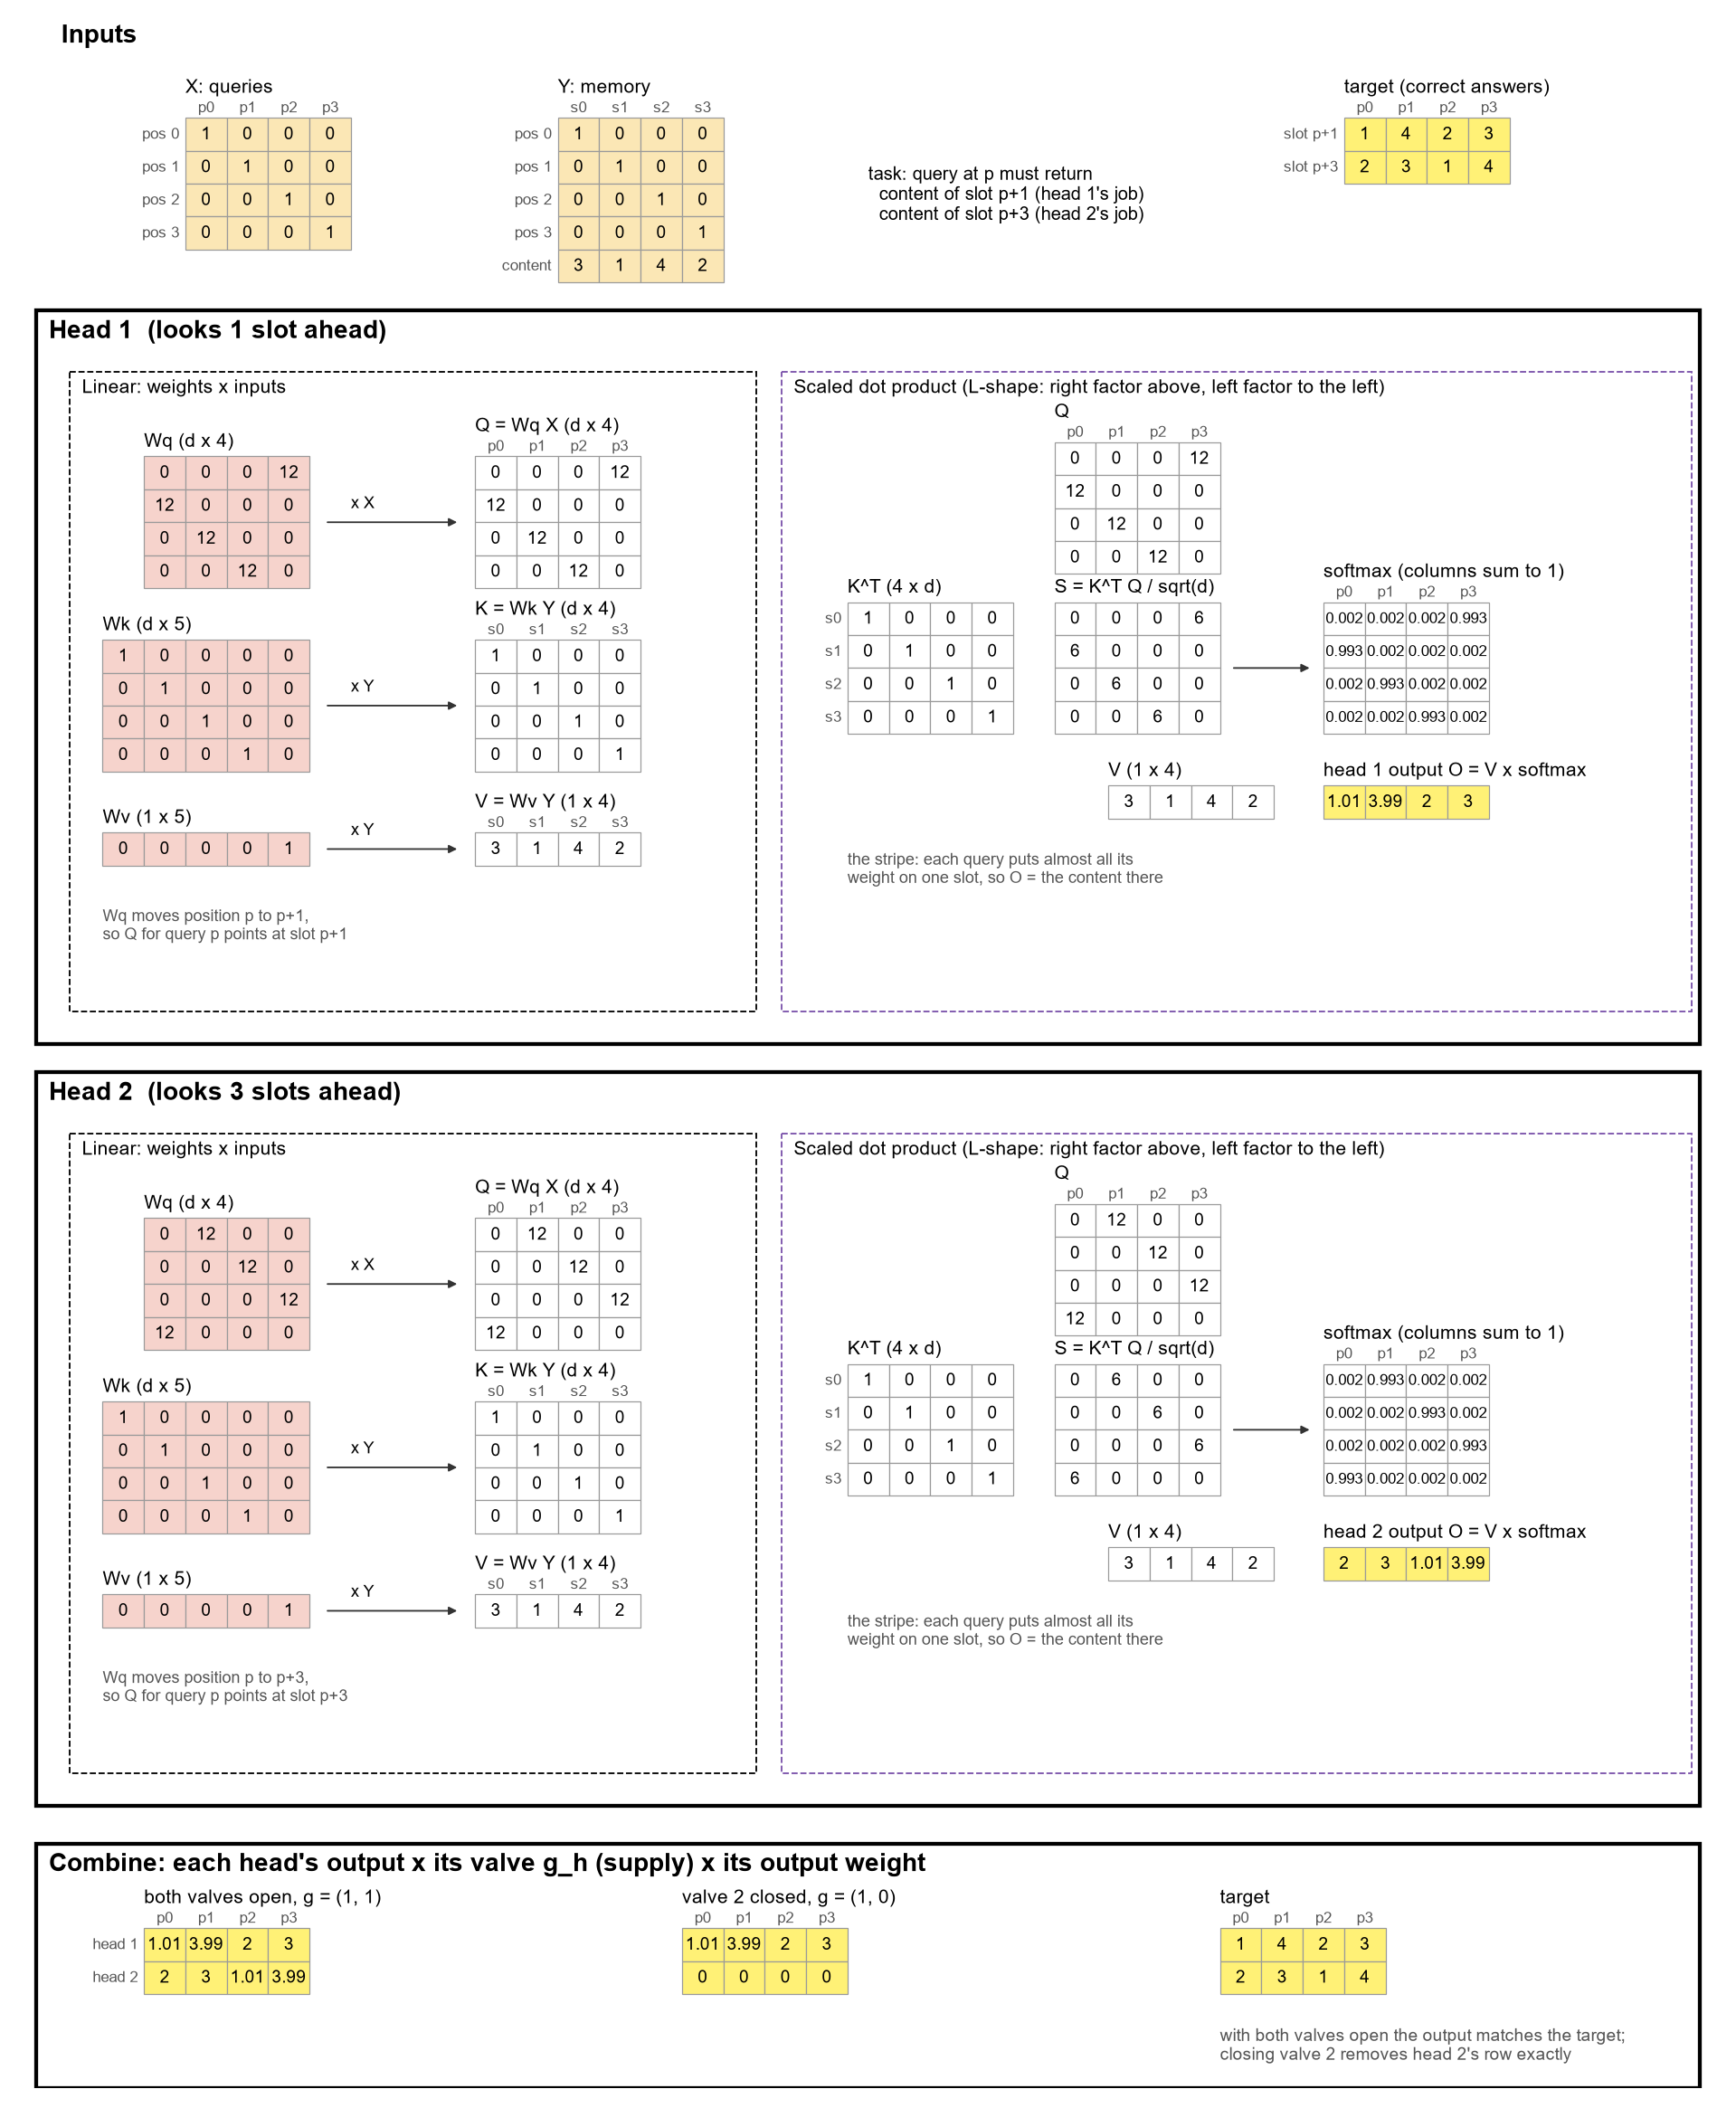

In [19]:
from IPython.display import Image, display      # show a picture inside the notebook
display(Image("../figures/fig_matrices.png", width=900))  # the L-shape figure

In [20]:
# the same numbers, recomputed: change SCALE, the contents or the shifts and rerun
Nn, dd, SCALE = 4, 4, 12.0                              # 4 slots, head size 4, sharpness of the query weights
contents = np.array([3.0, 1.0, 4.0, 2.0])               # the item stored in each slot
Xq = np.eye(Nn)                                         # queries: column t = one-hot of position t
Ym = np.vstack([np.eye(Nn), contents])                  # memory: column j = [one-hot j ; content j]
shift = lambda k: np.roll(np.eye(Nn), k, axis=0)        # matrix that moves position p to p + k
for h, k in ((1, 1), (2, 3)):                           # head 1 looks 1 ahead, head 2 looks 3 ahead
    Q = SCALE * shift(k) @ Xq                           # Q = Wq X: query p becomes "slot p + k"
    K = np.hstack([np.eye(Nn), np.zeros((Nn, 1))]) @ Ym # K = Wk Y: keep the slot positions only
    V = np.array([[0, 0, 0, 0, 1.0]]) @ Ym              # V = Wv Y: keep the contents only
    S = K.T @ Q / np.sqrt(dd)                           # scores, slots x queries: the stripe of 6s
    A = np.exp(S) / np.exp(S).sum(0, keepdims=True)     # softmax down each column (each query's weights)
    print(f"head {h}: output {np.round(V @ A, 2).ravel()}   target {contents[(np.arange(Nn) + k) % Nn]}")  # V x softmax

head 1: output [1.01 3.99 2.   3.  ]   target [1. 4. 2. 3.]
head 2: output [2.   3.   1.01 3.99]   target [2. 3. 1. 4.]


## 7. The collateral rule, running during training

**Idea.** Train with all heads on for a while. Then, every 25 steps:
1. compute every open head's collateral value on a fresh batch;
2. if the cheapest head is worth less than a **price**, close it;
3. a closed head **fades** out gradually (its gain falls by 1/50 per step), so the others
   take over its job smoothly, as vessels constrict gradually.

**Your turn.** Extend `train_dense` into `train_rule(H=8)`:
1. keep a list `open_` of booleans and a tensor `tone` of gains, all ones;
2. use `tone` as the gate in the forward pass;
3. after step 400, every 25 steps, get each head's outputs on a fixed probe batch, call
   `collateral_values`, and close the cheapest open head if its value is below `price = 0.03`;
4. every step, move `tone` toward the open/closed targets by at most 1/50.
Record the loss and the number of heads with supply at every step.

seed 0: heads kept 2 of 8 (task needs 2);  final loss 0.0001
seed 1: heads kept 2 of 8 (task needs 2);  final loss 0.0000
seed 2: heads kept 3 of 8 (task needs 2);  final loss 0.0000


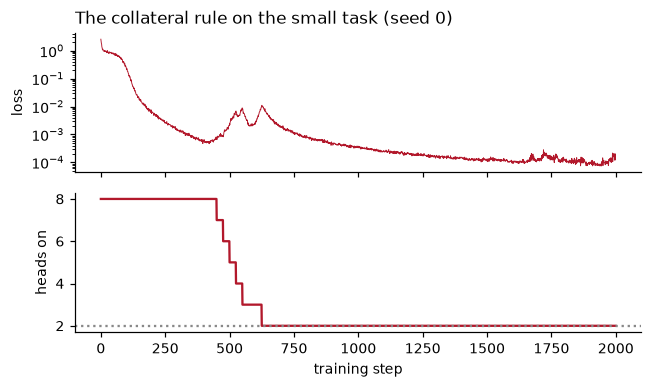

In [21]:
def train_rule(H=8, steps=2000, start=400, every=25, price=0.03, taper=50, seed=0):
    torch.manual_seed(seed)                        # fixed starting weights
    model = Heads(H)                               # 8 heads, more than the task needs
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)   # optimiser
    open_, tone = [True] * H, torch.ones(H)        # every head open, every valve at 1
    pq, pmem, pans, *_ = make_batch(512, torch.Generator().manual_seed(1))  # fixed batch for valuing heads
    history = []                                   # (loss, heads on) at every step
    for step in range(steps):                      # each training step:
        q, mem, ans, *_ = make_batch(128)          #   fresh training examples
        loss = F.mse_loss(model(q, mem, tone), ans)  #   run the layer with the current valves
        opt.zero_grad(); loss.backward(); opt.step()  #   update the weights
        if step >= start and (step - start) % every == 0:   #   after step 400, every 25 steps:
            with torch.no_grad():                            #     no gradients needed to value heads
                o = model.outputs(pq, pmem).numpy()          #     every head's blends on the probe batch
            values = collateral_values([o[:, h] for h in range(H)], pans.numpy(),
                                       [h for h in range(H) if open_[h]])  #     what nobody else can cover
            cheapest = min(values, key=values.get)           #     the least valuable open head
            if sum(open_) > 1 and values[cheapest] < price:  #     worth less than the price?
                open_[cheapest] = False                      #     close it
        goal = torch.tensor([1.0 if o_ else 0.0 for o_ in open_])  #   1 for open, 0 for closed
        tone += (goal - tone).clamp(-1 / taper, 1 / taper)          #   fade toward it by at most 1/50
        history.append((loss.item(), int((tone > 0).sum())))        #   record loss and heads still on
    return open_, np.array(history)                # which heads survived, and the history


runs = [train_rule(seed=s) for s in range(3)]      # three runs with different seeds
for s, (open_, hist) in enumerate(runs):
    print(f"seed {s}: heads kept {sum(open_)} of 8 (task needs {R});  final loss {hist[-50:, 0].mean():.4f}")

hist = runs[0][1]                                  # plot the first run
fig, ax = plt.subplots(2, 1, figsize=(6, 3.6), sharex=True)   # two plots stacked, same x axis
ax[0].semilogy(hist[:, 0], color=RED, lw=0.6); ax[0].set_ylabel("loss")       # loss on a log scale
ax[1].plot(hist[:, 1], color=RED); ax[1].axhline(R, color=GREY, ls=":"); ax[1].set_ylabel("heads on")  # heads with supply
ax[1].set_xlabel("training step")                  # x axis label
ax[0].set_title("The collateral rule on the small task (seed 0)", loc="left")  # title
plt.tight_layout(); plt.show()                     # draw it

That is the whole method in about 30 lines. On this small task it usually lands on the
right number of heads and occasionally keeps one spare. The full experiments below use the
same idea at a larger size, with more seeds and the controls.

## 8. What the full experiments found (main task, 32 heads)

The repo's version: 32 heads, $N = 16$, tasks needing $k^\star = 2, 3, 4, 6, 8$ heads, 10 seeds
each. The controls change one ingredient at a time:
- **ordinary importance**: value a head *without* letting the others adjust;
- **random choice**: close a head at the same moments, but chosen at random;
- **standard pruning** (Michel et al. 2019): remove the least important head until the loss
  gets worse.

Two numbers matter: did it keep **exactly** $k^\star$ heads, and did it **never break the
model** (never go back above the "solved" loss) while removing heads?

In [22]:
from hemo.config import Cfg                       # the settings every run was made with

DEFAULT = Cfg()                                    # default settings (older runs did not store newer ones)
RUNS = [pickle.load(open(f, "rb")) for d in ("../results", "../results/proposal", "../results/confirm", "../results/l0")
        for f in glob.glob(d + "/*.pkl")]          # load every saved run
RUNS = [r for r in RUNS if isinstance(r, dict) and "hist" in r and "ledger" in r.get("hist", {})]  # keep training runs
PIN = dict(task="multi_relation", steps=4000, d_k=32, demand="outnorm_ema", leak=0.0, probe_every=25,
           prune_stop=1, conserve=1, local_value="refit", plant_copies=0, head_dropout=0.0,
           trial=0, target_frac=0.02, budget_hold_frac=0.25, taper=0, price_frac=0.01, l0_lambda=0.01)
get = lambda r, k: r["cfg"].get(k, getattr(DEFAULT, k))   # a run's setting (default if not stored)
runs_of = lambda **w: [r for r in RUNS if all(get(r, k) == v for k, v in {**PIN, **w}.items())]  # runs matching settings


def kept(r):                                       # heads with supply, median over the last 40% of training
    on = (r["hist"]["ledger"] > 0).sum(1)          # heads with a valve above 0, at every step
    return float(np.median(on[int(0.6 * len(on)):]))  # median over the last 40% of training


def stayed_solved(r):                              # never back above the solved bar after first reaching it
    h, bar = r["hist"], 0.02 * r["trivial"]        # the bar: 2% of a know-nothing model's loss
    ls = [l for s, l in zip(h["val_step"], h["val_loss"]) if s >= get(r, "budget_hold_frac") * get(r, "steps")]  # losses after pruning starts
    first = next((i for i, l in enumerate(ls) if l < bar), None)   # first time it was solved
    return first is not None and max(ls[first:]) <= bar             # never above the bar afterwards


RULE = dict(supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.1, conserve=0)  # the collateral rule's settings
arms = {"collateral rule": (RULE, (2, 3, 4, 6, 8)),     # each rule: (its settings, task sizes run)
        "ordinary importance": ({**RULE, "local_value": "ablate"}, (2, 4, 8)),
        "random choice": ({**RULE, "local_value": "random"}, (2, 4, 8)),
        "standard pruning": (dict(supply="prune"), (2, 3, 4, 6, 8))}
print(f"{'rule':<34}{'runs':>5}{'exact count':>13}{'never broke':>13}")
for name, (kw, sizes) in arms.items():             # one line per rule
    rs = [r for k in sizes for r in runs_of(**kw, n_rel=k)]   # all its runs, every task size
    print(f"{name:<34}{len(rs):>5}{sum(kept(r) == get(r, 'n_rel') for r in rs):>9}/{len(rs)}"
          f"{sum(stayed_solved(r) for r in rs):>9}/{len(rs)}")
for lam in (0.05, 0.2, 1.0):                       # the learned-gate baseline at three penalty strengths
    rs = [r for k in (2, 4, 8) for r in runs_of(supply="l0", budget_hold_frac=0.1, l0_lambda=lam, n_rel=k)]  # its runs
    print(f"{'learned gates, penalty ' + str(lam):<34}{len(rs):>5}{sum(kept(r) == get(r, 'n_rel') for r in rs):>9}/{len(rs)}"
          f"{sum(stayed_solved(r) for r in rs):>9}/{len(rs)}")

rule                               runs  exact count  never broke
collateral rule                      50       47/50       50/50
ordinary importance                  30        2/30       30/30
random choice                        30       30/30        6/30
standard pruning                     36       34/36        0/36
learned gates, penalty 0.05           9        0/9        1/9
learned gates, penalty 0.2            9        0/9        1/9
learned gates, penalty 1.0            9        3/9        0/9


Only the collateral rule does both. Ordinary importance keeps redundant heads; random
choice and standard pruning get the count but break the model on the way. The classic
learned-gate method (Voita et al. 2019: a learnable on/off gate per head plus a penalty for
every open head) keeps too many heads at a weak penalty and cuts too far at a strong one;
no single penalty works for every task size. Two more checks
from the same runs: started with every head duplicated, the collateral rule keeps exactly 4
heads and never both copies of a pair (10 of 10 seeds), and the right count holds at every
price from 0.01 to 0.1.

## 9. Backup heads when heads can fail

**Idea.** If heads fail at random during training (each with chance $p$), a spare head
becomes worth something: it saves the task when another fails. Any $R$ working heads can do
the job (they blend all the answers), so a head is worth something only when, without it,
fewer than $R$ heads would be working:

$$v(B) = \frac{1-p}{R}\ \Pr\big[\text{fewer than } R \text{ of the other } B-1 \text{ heads work}\big].$$

The rule keeps adding heads while $v(B)$ is at least the price.

**By hand**, $R = 4$, $p = 0.1$, price $0.03$: with $B = 5$ heads, the other 4 all work with
chance $0.9^4 = 0.656$, so fewer than 4 work with chance $0.344$, and
$v(5) = 0.9 \times 0.344 / 4 = 0.077 > 0.03$: keep 5. With $B = 6$:
$v(6) = 0.9 \times 0.081 / 4 = 0.018 < 0.03$: stop. Prediction: **5 heads**.

**Your turn.** Write `predict(R, p, price)` with `math.comb` for the binomial probability,
and check it returns 5 for the example.

In [23]:
def predict(R, p, price=0.03):                   # heads the rule should keep when heads fail with chance p
    q = 1 - p                                      # chance a head works
    def value(B):                                  # worth of one head when B heads are kept
        fewer = sum(comb(B - 1, a) * q ** a * p ** (B - 1 - a) for a in range(min(R - 1, B - 1) + 1))  # P[fewer than R of the others work]
        return q * fewer / R                       # it must work itself, and it saves 1/R of the loss
    return max(B for B in range(1, 33) if value(B) >= price)   # the largest B still worth its price


print("predicted heads kept, R = 4, p = 0.1:", predict(4, 0.1))
assert predict(4, 0.1) == 5                        # must match the hand calculation
print("\nREAL RESULT (predictions written before the runs):")
print(f"{'R':>2} {'p':>5} {'predicted':>10} {'measured (per seed)':>22}")
for Rr in (2, 4):                                  # tasks needing 2 and 4 heads
    for pp in (0.05, 0.1, 0.2, 0.3):               # four failure rates
        rs = runs_of(**RULE, n_rel=Rr, head_dropout=pp)  # the runs at this task size and failure rate
        print(f"{Rr:>2} {pp:>5} {predict(Rr, pp):>10} {str([int(kept(r)) for r in rs]):>22}")

predicted heads kept, R = 4, p = 0.1: 5

REAL RESULT (predictions written before the runs):
 R     p  predicted    measured (per seed)
 2  0.05          3              [3, 3, 3]
 2   0.1          3              [3, 3, 3]
 2   0.2          4              [4, 4, 4]
 2   0.3          4              [5, 4, 5]
 4  0.05          5              [5, 5, 4]
 4   0.1          5              [5, 5, 5]
 4   0.2          6              [6, 6, 6]
 4   0.3          7              [7, 7, 7]


**Do the spares actually protect the model?** After training with failures, switch off one
kept head at a time (nobody re-fits) and measure the loss, in units of the solved bar.

In [24]:
ROB = [pickle.load(open(f, "rb")) for f in glob.glob("../results/robust/*.pkl")]   # runs with the knockout check
print(f"{'p fail':>7}{'heads kept':>16}{'worst head removed (x bar)':>30}")
for pp in sorted({r["cfg"].get("head_dropout", 0.0) for r in ROB}):          # each failure rate
    rs = [r for r in ROB if r["cfg"].get("head_dropout", 0.0) == pp]          # the runs at this failure rate
    bar = 0.02 * rs[0]["trivial"]                                             # the solved bar
    worst = np.median([max(r["knockout"]["per_head"].values()) / bar for r in rs])   # worst single head removed
    print(f"{pp:>7}{str([len(r['knockout']['per_head']) for r in rs]):>16}{worst:>30.1f}")

 p fail      heads kept    worst head removed (x bar)
    0.0       [4, 4, 4]                          31.1
    0.1       [6, 5, 5]                          13.0
    0.2       [6, 6, 6]                          14.0
    0.3       [7, 8, 7]                          13.4


With no spares, losing one head breaks the model (about 31 times the bar). With spares the
damage is about 2.4 times smaller, but still well above the bar: the spares reduce, but do
not remove, the damage of losing a head.

## 10. A second circuit: two-layer induction

**Idea.** In a sequence like `... 45 26 38 57 ... 45 26 38 ?`, the next token is `57`: find
the earlier copy of the current token and copy what came after it. Language models learn
this with two heads in two layers:
- a **previous-token head** (layer 1): each position looks one step back, so position `57`
  learns "the token before me was `38`";
- an **induction head** (layer 2): at the current `38`, look for the position whose previous
  token was `38`, which is `57`, and copy it.

So the known answer is **one head in each layer**. One layer alone cannot do it, whatever its
size (checked: about 16% accuracy against 99.8% with one head per layer).

**By hand.** Sequence positions: `0:11 1:45 2:26 3:38 4:57 5:14 6:45 7:26 8:38`. At position 8
(token 38) the induction head should attend to position 4: the earlier 38 is at 3, plus one.

**The model** (`src/hemo/induction.py`) is a small but complete attention-only transformer:
token and position embeddings, two causal self-attention layers added into a "residual
stream", and an unembedding that scores every possible next token. Every head has a valve,
exactly as in the main task. Here is its code with a note on every line:

In [25]:
from hemo.induction import AttnLayer, InductionNet   # the two-layer induction model

show(AttnLayer.__init__, {
    "super().__init__()": "standard PyTorch set-up",
    "self.H, self.d_head = H, d_head": "heads in this layer, and the size of each head",
    "self.W_q = nn.Linear": "query weights for all heads of this layer",
    "self.W_k = nn.Linear": "key weights for all heads",
    "self.W_v = nn.Linear": "value weights for all heads",
    "self.W_o = nn.Parameter": "each head's own output weights: (H, d_head, d_model)",
})
print()
show(AttnLayer.forward, {
    "B, T, _ = x.shape": "batch size and sequence length",
    "split = lambda": "cut H*d_head numbers into H heads",
    "q, k, v = split": "queries, keys and values all from the same sequence (self-attention)",
    "scores = q @ k.transpose": "every position's score for every position",
    "mask = torch.ones": "causal mask: a position may look only at itself and earlier positions",
    "attn = F.softmax(scores.masked_fill": "later positions get minus infinity, so weight 0",
    "return torch.einsum": "each head's blend, mapped into the residual stream by its own W_o",
})

    def __init__(self, d_model, d_head, H):
        super().__init__()    # <- standard PyTorch set-up
        self.H, self.d_head = H, d_head    # <- heads in this layer, and the size of each head
        self.W_q = nn.Linear(d_model, H * d_head, bias=False)    # <- query weights for all heads of this layer
        self.W_k = nn.Linear(d_model, H * d_head, bias=False)    # <- key weights for all heads
        self.W_v = nn.Linear(d_model, H * d_head, bias=False)    # <- value weights for all heads
        self.W_o = nn.Parameter(torch.randn(H, d_head, d_model) / math.sqrt(H * d_head))    # <- each head's own output weights: (H, d_head, d_model)

    def forward(self, x):
        """Per-head contributions to the residual stream (B, H, T, d_model), and attention."""
        B, T, _ = x.shape    # <- batch size and sequence length
        split = lambda t: t.view(B, T, self.H, self.d_head).transpose(1, 2)    # <- cut H*d_head numbers into H heads
        q, k, v = split(self.W_q(x)), spl

In [26]:
show(InductionNet.__init__, {
    "super().__init__()": "standard PyTorch set-up",
    "h1 = cfg.heads if": "heads in layer 1",
    "h2 = cfg.heads if": "heads in layer 2",
    "self.sizes = [h1, h2]": "remember both",
    "self.embed = nn.Embedding": "token embedding: each token id -> a vector",
    "self.pos = nn.Parameter": "position embedding: each position -> a learned vector",
    "self.layers = nn.ModuleList": "the two attention layers",
    "self.unembed = nn.Linear": "turns the final vector into a score for every possible next token",
    "self.H = h1 + h2": "total heads; valves are numbered layer 1 first",
})
print()
show(InductionNet.residual, {
    "x = self.embed(tokens) + self.pos": "start of the residual stream: token + position",
    "gate = torch.ones(self.H": "no valves given: every head on",
    "attns, i = [], 0": "attention patterns (if asked), and which valve comes next",
    "for layer in self.layers:": "layer 1, then layer 2",
    "out, attn = layer(x)": "every head's contribution",
    "x = x + (out * gate": "THE VALVE: each head's contribution times its gain, added into the stream",
    "attns.append": "keep the attention patterns if asked (for the role scores)",
    "i += layer.H": "move on to the next layer's valves",
    "return x, attns": "the final stream (and patterns)",
})
print()
show(InductionNet.forward, {"return self.unembed": "scores for the next token"})

    def __init__(self, cfg):
        super().__init__()    # <- standard PyTorch set-up
        h1 = cfg.heads if cfg.heads1 < 0 else cfg.heads1    # <- heads in layer 1
        h2 = cfg.heads if cfg.heads2 < 0 else cfg.heads2    # <- heads in layer 2
        self.sizes = [h1, h2]    # <- remember both
        self.embed = nn.Embedding(cfg.vocab, cfg.d_model)    # <- token embedding: each token id -> a vector
        self.pos = nn.Parameter(torch.randn(seq_len(cfg), cfg.d_model) * 0.1)    # <- position embedding: each position -> a learned vector
        self.layers = nn.ModuleList([AttnLayer(cfg.d_model, cfg.d_head, h) for h in self.sizes if h > 0])    # <- the two attention layers
        self.unembed = nn.Linear(cfg.d_model, cfg.vocab)    # <- turns the final vector into a score for every possible next token
        self.H = h1 + h2    # <- total heads; valves are numbered layer 1 first

    def residual(self, tokens, gate=None, keep_attn=False):
        """Final residual stream. ga

**Real result** (8 heads per layer, 10 seeds):

In [27]:
IND = [pickle.load(open(f, "rb")) for f in glob.glob("../results/induction/*.pkl")]   # every induction run


def kept_layers(r):                                # heads kept in layer 1 and in layer 2
    h1 = r["sizes"][0]                             # number of heads in layer 1
    return int(r["kept"][:h1].sum()), int(r["kept"][h1:].sum())   # (kept in layer 1, kept in layer 2)


def ind_group(**w):                                # runs with these settings (older runs lack "probe": it was "mse")
    return [r for r in IND if all(r["cfg"].get(k, v if k != "probe" else "mse") == v for k, v in w.items())]  # matching runs


groups = {                                         # the three versions of the rule we tried
    "first version (linear read-out values)": dict(rule="collateral", probe="mse", price_frac=0.03, steps=3000),
    "loss-based values, keep it solved": dict(rule="collateral", probe="logit_tone", price_mode="bar",
                                              price_frac=0.02, steps=6000, trial=0, squeeze_at=0.0),
    "... plus trial closure": dict(rule="collateral", probe="logit_tone", price_mode="bar",
                                   price_frac=0.02, steps=6000, trial=1),
}
for name, w in groups.items():                     # one line per version of the rule
    rs = ind_group(**w)                            # its 10 runs
    ks = [kept_layers(r) for r in rs]              # heads kept per layer in each run
    print(f"{name:<42} n={len(rs):>2}  exactly (1, 1): {sum(k == (1, 1) for k in ks)}/{len(rs)}"
          f"  solved: {sum(r['final_loss'] <= r['bar'] for r in rs)}/{len(rs)}  kept: {ks}")

first version (linear read-out values)     n=10  exactly (1, 1): 0/10  solved: 10/10  kept: [(3, 4), (3, 3), (2, 3), (2, 3), (3, 3), (3, 3), (3, 3), (2, 3), (3, 3), (3, 4)]
loss-based values, keep it solved          n=10  exactly (1, 1): 0/10  solved: 10/10  kept: [(2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1)]
... plus trial closure                     n=20  exactly (1, 1): 8/20  solved: 17/20  kept: [(1, 1), (1, 1), (1, 1), (3, 1), (1, 1), (1, 1), (1, 1), (2, 1), (1, 1), (1, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1)]


Every kept head has the right role. The loss-based version keeps **one** induction head but
**two** previous-token heads, because those two share the job and the network needs time to
move it onto one. Letting it try (trial closure) reaches exactly one head per layer in 8 of
10 runs, but the failed tries push the loss above the solved bar, so the model no longer
stays solved throughout. On induction the rule finds the right roles with one spare; the
exact minimum costs stability.

## 11. What holds, and what does not

**Holds**
- The task needs exactly $R$ heads, and the loss of every smaller model follows
  $(1 - k/R)$ (sections 3, 4).
- A head at zero supply is removed exactly (section 5).
- Valuing a head by what the others cannot cover removes duplicates that ordinary importance
  keeps (sections 6, 8).
- On the main task the collateral rule keeps exactly the needed heads and never breaks the
  model while pruning, unlike standard pruning (section 8).
- With random head failures it keeps the number of backups a simple formula predicts
  (section 9).

**Does not hold, or is not claimed**
- The "fixed total supply" from autoregulation is not needed (it was tested and dropped).
- Final loss is a few times higher than a fully trained dense model, at about a third of
  the compute.
- On induction it keeps one spare previous-token head; forcing the minimum costs stability
  (section 10).
- Only small synthetic tasks so far; no real language model yet.
- The biology is inspiration (collateral circulation, gradual vessel pruning), not evidence
  about the brain.